In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('/Users/nheechan/Desktop/DS capstone/water-quality-england/data/England_dataset.csv')
data.head()

,Country,Area,Waterbody Type,Date,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,CCME_WQI
0,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,23.40,152.00,10.2,3.900,7.78,11.46,0.20,4.5,42.847368,Poor
1,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,21.30,102.00,10.2,3.430,7.78,8.30,0.20,4.5,43.496934,Poor
2,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,4.03,12.50,10.2,0.495,7.78,8.90,3.83,4.5,60.444542,Marginal
3,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,5.09,4.18,10.2,0.780,7.78,8.30,2.11,4.5,59.285522,Marginal
4,England,MISC.10KM SQ HISTON.................TL46,River,01-01-2019,5.10,3.58,10.2,0.728,7.78,8.20,1.46,4.5,59.820608,Marginal


## EDA checklist:
- Check for the distribution of observations by Water Quality Class
- Check the range for CCME_Values for each class
- Check for unique values of Area and Waterbody
- Check the date range
- Check for missing values

### Data distribution

In [ ]:
## check for null values
data.isnull().sum()
## this dataset has been preprocessed to handle missing values - using median imputation

Country                             0
Area                                0
Waterbody Type                      0
Date                                0
Ammonia (mg/l)                      0
Biochemical Oxygen Demand (mg/l)    0
Dissolved Oxygen (mg/l)             0
Orthophosphate (mg/l)               0
pH (ph units)                       0
Temperature (cel)                   0
Nitrogen (mg/l)                     0
Nitrate (mg/l)                      0
CCME_Values                         0
CCME_WQI                            0
dtype: int64

In [5]:
data.describe().round(2)

,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values
count,2129198.00,2129198.00,2129198.00,2129198.00,2129198.00,2129198.00,2129198.00,2129198.00,2129198.00
mean,1.53,5.97,10.22,0.91,7.73,11.58,6.63,5.56,80.74
std,6.47,18.76,1.56,2.21,0.46,4.13,6.51,5.12,18.13
min,0.00,0.00,0.00,0.00,0.00,-5.26,0.00,0.00,31.30
25%,0.03,1.83,10.10,0.06,7.53,8.80,2.49,2.99,70.22
50%,0.10,2.70,10.20,0.14,7.78,11.46,5.00,4.50,88.76
75%,0.50,3.46,10.90,0.44,7.99,14.20,7.98,6.15,93.07
max,200.00,255.00,20.00,100.00,14.00,97.50,46.00,153.00,100.00


In [6]:
stat_summary = data.describe().round(2)
stat_summary2 = stat_summary.transpose()
stat_summary2.to_csv('/Users/nheechan/Desktop/DS capstone/water-quality-england/data/stat_summary.csv')


- Temperature: max of 97.5°C is near boiling — almost certainly an outlier or data entry error
- pH: min of 0 and max of 14 are the theoretical extremes — possible but worth flagging
- Orthophosphate: max of 100 mg/l is unusually high
- Ammonia: max of 200 mg/l is very high

### Check for outliers

In [3]:
def std_range(col, l, h):
    count = sum(1 for x in col if l <= x <= h)
    return count

In [5]:
def calculate_outlier(data, col):
    col_name = data[col]
    
    # calculate quantiles
    q1 = np.percentile(col_name, 25)
    q2 = np.percentile(col_name, 50)
    q3 = np.percentile(col_name, 75)
    
    # calculate IQR
    iqr = q3 - q1
    
    # calculate lower and upper fences
    inner_fence_low = q1 - 1.5 * iqr
    inner_fence_high = q3 + 1.5 * iqr
    outer_fence_low = q1 - 3 * iqr
    outer_fence_high = q3 + 3 * iqr
    
    # count outliers
    inner = std_range(col_name, inner_fence_low, inner_fence_high)
    outer = std_range(col_name, outer_fence_low, outer_fence_high)
    
    value_count = len(col_name)
    potential_outliers = ((value_count - inner) / value_count) * 100
    possible_outliers = ((value_count - outer) / value_count) * 100
    
    print("Q1 = " , q1, ", Q2 = " , q2, ", Q3 = " , q3, ", IQR = " , iqr)
    print("inner fence low: ", inner_fence_low, ", inner fence high: ", inner_fence_high)
    print("outer fence low: ", outer_fence_low, ", outer fence high: ", outer_fence_high)
    print("potential outliers: ", potential_outliers, "%")
    print("possible outliers: ", possible_outliers, "%")

In [6]:
column_name = "Ammonia (mg/l)"
print("-------------",column_name,"--------------")
calculate_outlier(data, column_name)

column_name = "Biochemical Oxygen Demand (mg/l)"
print("-------------",column_name,"--------------")
calculate_outlier(data, column_name)

column_name = "Dissolved Oxygen (mg/l)"
print("-------------",column_name,"--------------")
calculate_outlier(data, column_name)

column_name = "Orthophosphate (mg/l)"
print("-------------",column_name,"--------------")
calculate_outlier(data, column_name)

column_name = "pH (ph units)"
print("-------------",column_name,"--------------")
calculate_outlier(data, column_name)

column_name = "Temperature (cel)"
print("-------------",column_name,"--------------")
calculate_outlier(data, column_name)

column_name = "Nitrogen (mg/l)"
print("-------------",column_name,"--------------")
calculate_outlier(data, column_name)

column_name = "Nitrate (mg/l)"
print("-------------",column_name,"--------------")
calculate_outlier(data, column_name)

------------- Ammonia (mg/l) --------------
Q1 =  0.03 , Q2 =  0.098 , Q3 =  0.5 , IQR =  0.47
inner fence low:  -0.6749999999999999 , inner fence high:  1.205
outer fence low:  -1.38 , outer fence high:  1.91
potential outliers:  14.906692566872598 %
possible outliers:  11.660634661501655 %
------------- Biochemical Oxygen Demand (mg/l) --------------
Q1 =  1.83 , Q2 =  2.7 , Q3 =  3.46 , IQR =  1.63
inner fence low:  -0.6149999999999998 , inner fence high:  5.904999999999999
outer fence low:  -3.0599999999999996 , outer fence high:  8.35
potential outliers:  15.468641244261924 %
possible outliers:  10.284670566100475 %
------------- Dissolved Oxygen (mg/l) --------------
Q1 =  10.1 , Q2 =  10.2 , Q3 =  10.9 , IQR =  0.8000000000000007
inner fence low:  8.899999999999999 , inner fence high:  12.100000000000001
outer fence low:  7.6999999999999975 , outer fence high:  13.300000000000002
potential outliers:  18.02115162610523 %
possible outliers:  6.488922119971933 %
------------- Ortho

- Ammonia, Biochemical Oxygen, Orthophosphate have relatively large % of possible outliers - is it something worth exploring?
- Looking at the boxplot below, most variables have right-skewed distribution with a compressed IQR


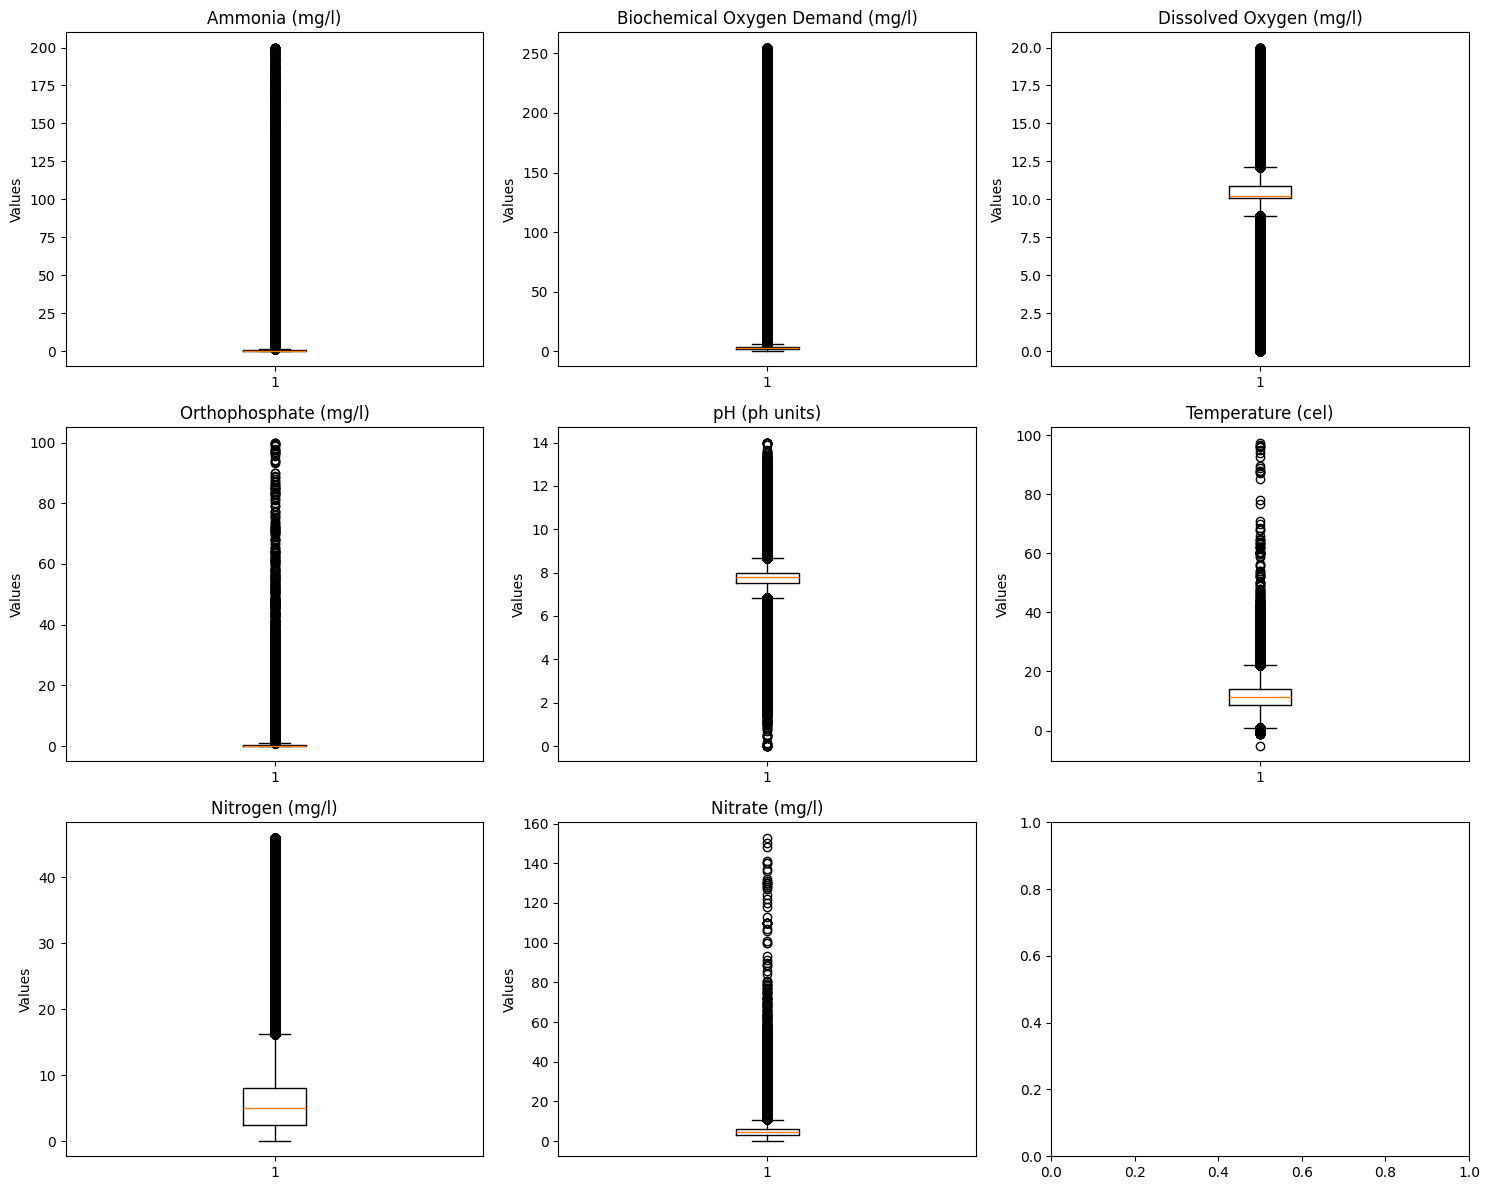

In [20]:
import matplotlib.pyplot as plt

numeric_cols = [
    'Ammonia (mg/l)', 'Biochemical Oxygen Demand (mg/l)',
    'Dissolved Oxygen (mg/l)', 'Orthophosphate (mg/l)',
    'pH (ph units)', 'Temperature (cel)',
    'Nitrogen (mg/l)', 'Nitrate (mg/l)'
]

fig, axes = plt.subplots(3,3, figsize = (15,12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(data[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Values')
    
plt.tight_layout()
plt.show()

Update 04/26/2026: Won't remove outliers at this point. Might come back to handle them after training the model and test their performance

In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2129198 entries, 0 to 2129197
Data columns (total 14 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Country                           str    
 1   Area                              str    
 2   Waterbody Type                    str    
 3   Date                              str    
 4   Ammonia (mg/l)                    float64
 5   Biochemical Oxygen Demand (mg/l)  float64
 6   Dissolved Oxygen (mg/l)           float64
 7   Orthophosphate (mg/l)             float64
 8   pH (ph units)                     float64
 9   Temperature (cel)                 float64
 10  Nitrogen (mg/l)                   float64
 11  Nitrate (mg/l)                    float64
 12  CCME_Values                       float64
 13  CCME_WQI                          str    
dtypes: float64(9), str(5)
memory usage: 227.4 MB


### Feature correlation

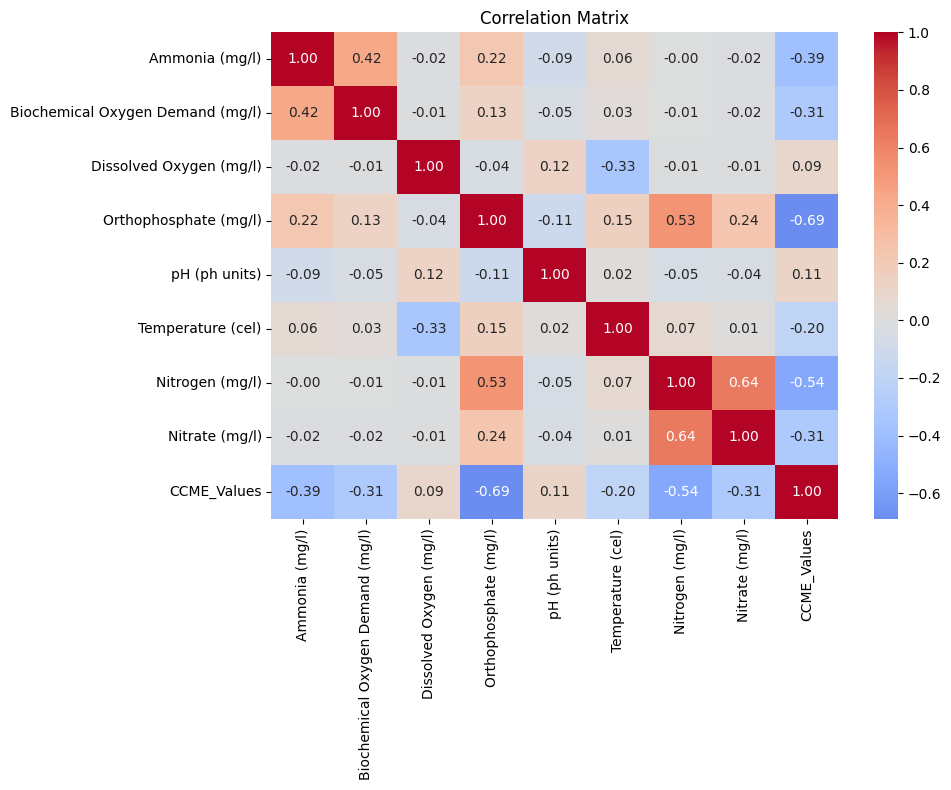

In [14]:
import seaborn as sns

cols = [
    'Ammonia (mg/l)', 'Biochemical Oxygen Demand (mg/l)',
    'Dissolved Oxygen (mg/l)', 'Orthophosphate (mg/l)',
    'pH (ph units)', 'Temperature (cel)',
    'Nitrogen (mg/l)', 'Nitrate (mg/l)', 'CCME_Values'
]

corr_matrix = data[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

- Orthophosphate has the largest negative relationship with CCME_values, followed by Nitrogen
- Nitrogen and Orthophosphate has a relatively strong positive relationship  

### Scatterplots: CCME Values vs Each Feature

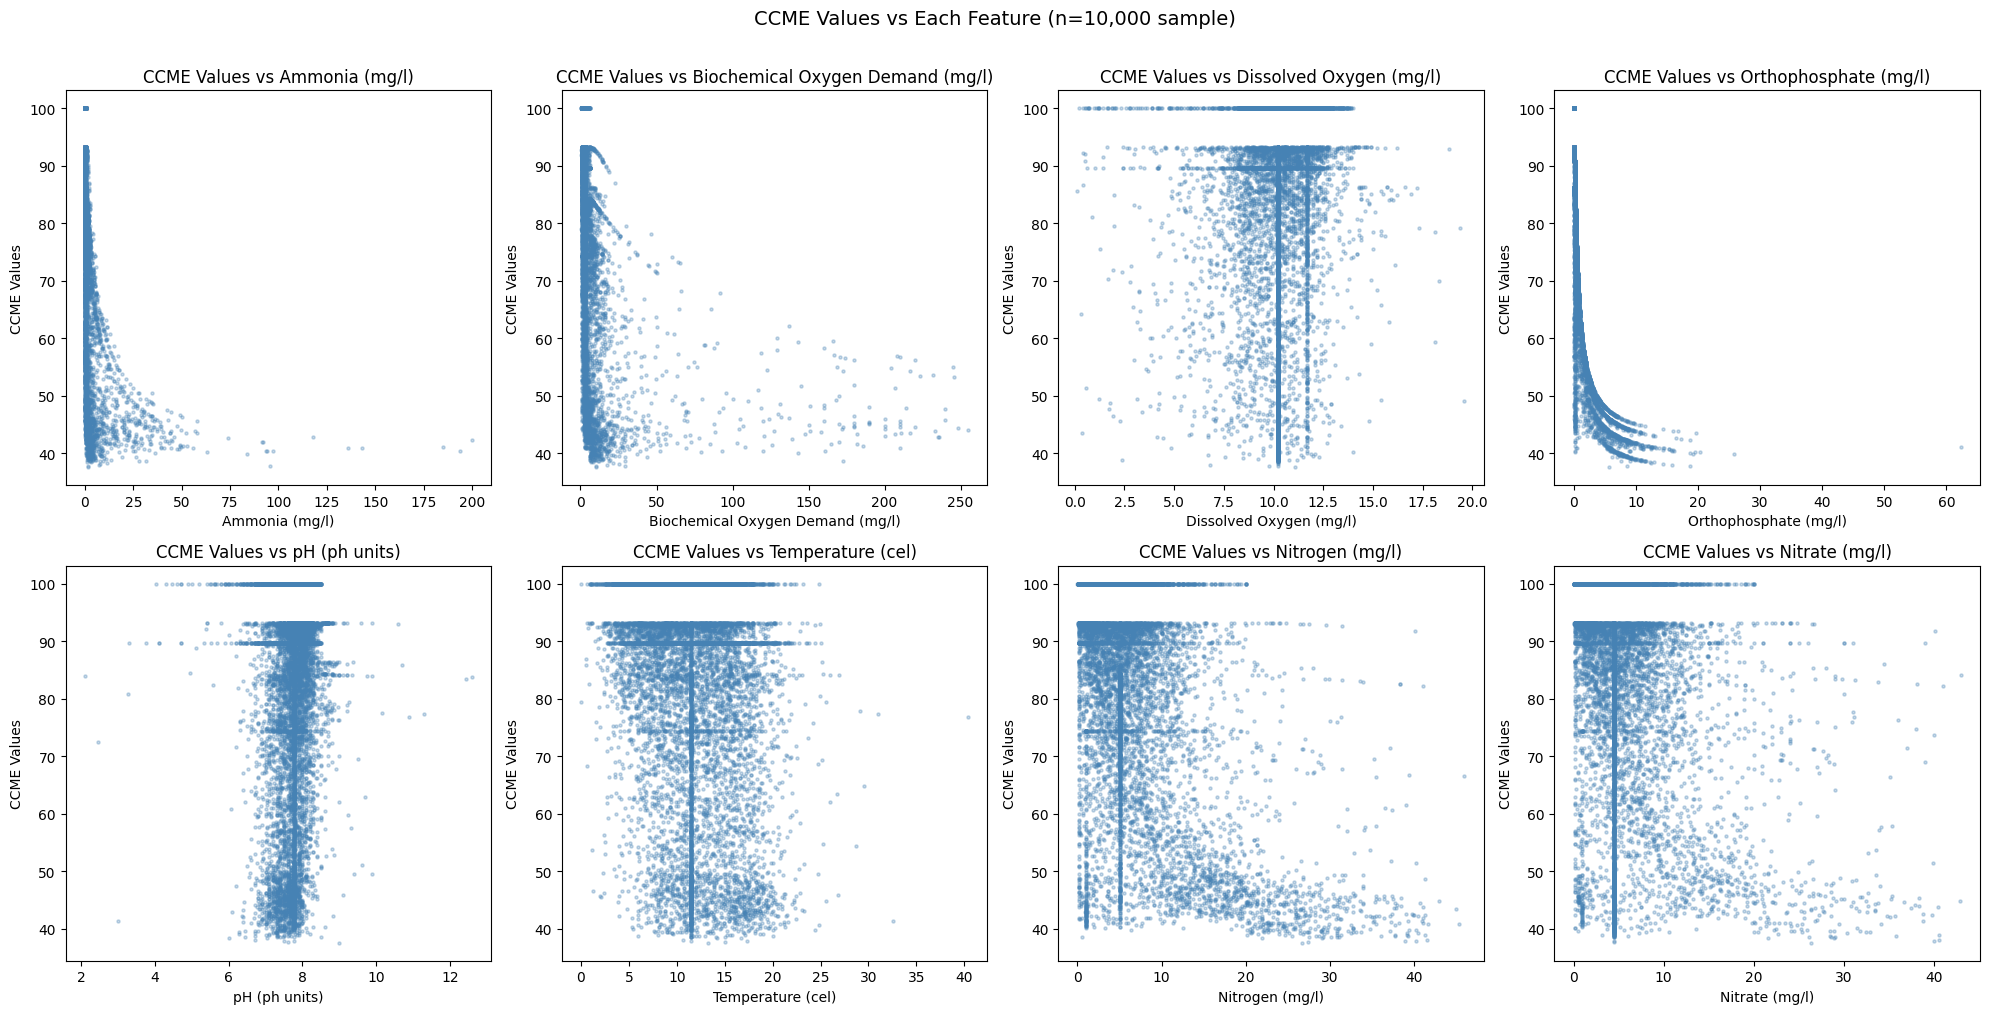

In [7]:
feature_cols = [
    'Ammonia (mg/l)', 'Biochemical Oxygen Demand (mg/l)',
    'Dissolved Oxygen (mg/l)', 'Orthophosphate (mg/l)',
    'pH (ph units)', 'Temperature (cel)',
    'Nitrogen (mg/l)', 'Nitrate (mg/l)'
]

sample = data[feature_cols + ['CCME_Values']].dropna().sample(n=10000, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(sample[col], sample['CCME_Values'], alpha=0.3, s=5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('CCME Values')
    axes[i].set_title(f'CCME Values vs {col}')

plt.suptitle('CCME Values vs Each Feature (n=10,000 sample)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/ccme_scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()

### WQI and WQC distribution

In [3]:
## Check the distribution of the target variable
print(data['CCME_WQI'].value_counts())

CCME_WQI
Good         919387
Excellent    445573
Marginal     325599
Fair         313260
Poor         125379
Name: count, dtype: int64


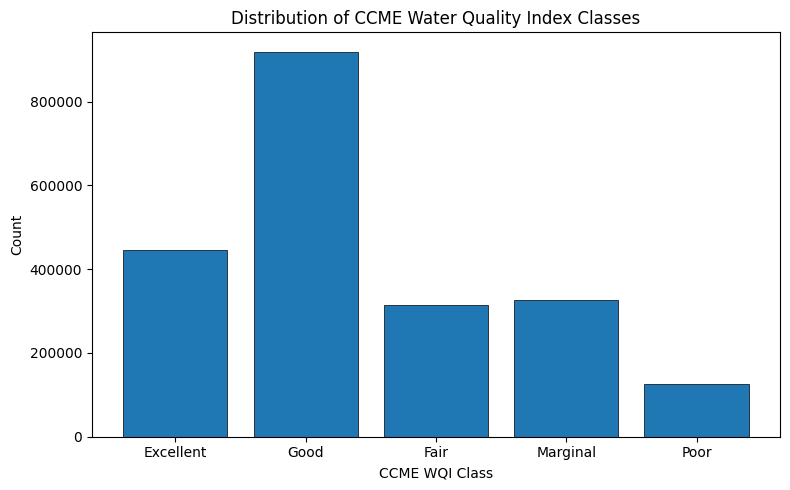

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

wqi_counts = data['CCME_WQI'].value_counts()
order = ['Excellent', 'Good', 'Fair', 'Marginal', 'Poor']
wqi_counts = wqi_counts.reindex(order).dropna()

ax.bar(wqi_counts.index, wqi_counts.values, edgecolor='black', linewidth=0.5)

ax.set_xlabel('CCME WQI Class')
ax.set_ylabel('Count')
ax.set_title('Distribution of CCME Water Quality Index Classes')
plt.tight_layout()
plt.savefig('../results/ccme_wqi_bar.png', dpi=150)
plt.show()


- Observation with Good WQC is 2 times larger than Excellent observations - class imbalance issue
- The difference in count between other classes are not that big

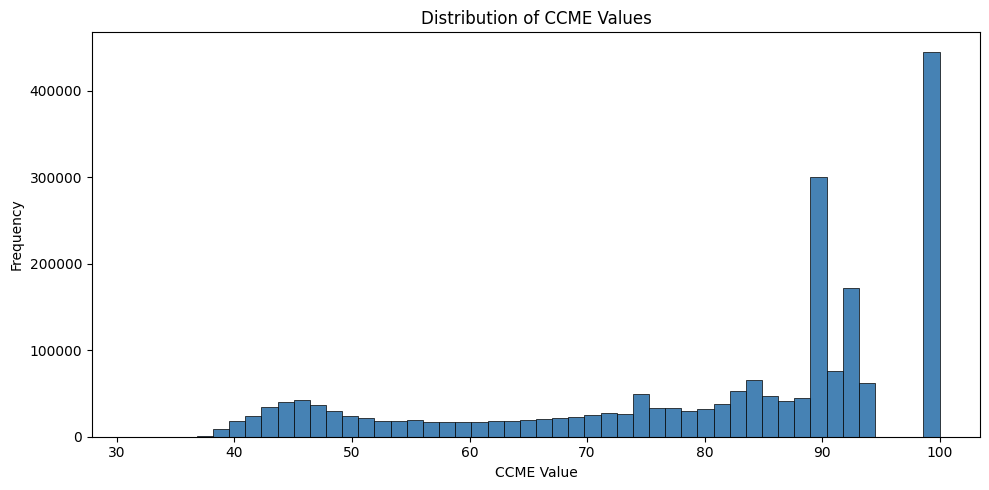

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(data['CCME_Values'].dropna(), bins=50, color='steelblue', edgecolor='black', linewidth=0.5)

ax.set_xlabel('CCME Value')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of CCME Values')
plt.tight_layout()
plt.savefig('../results/ccme_histogram.png', dpi=150)
plt.show()

The distribution of CCME value is left-skewed? - the model might bias towards CCME_values = 100

In [4]:
## Check the min and max values of CCME_Values for each CCME_WQI category
print(data.groupby('CCME_WQI')['CCME_Values'].agg(['min', 'max']))

                  min         max
CCME_WQI                         
Excellent  100.000000  100.000000
Fair        65.000089   79.998275
Good        80.000892   93.195661
Marginal    45.000017   64.999973
Poor        31.304144   44.999965


### Miscellaneous

In [5]:
## Check unique values for Area - might not be too useful
print(data['Area'].value_counts())

Area
MISC RIVER SAMPLES LUNE/WYRE               3050
RIVER BROCK AT A6 ROAD  BRIDGE             2517
DACRE BECK AT DACRE BRIDGE                 2279
RIVER WYRE AT ST MICHAELS                  2241
RIVER EDEN AT SHEEPMOUNT                   1766
                                           ... 
EMBER BELOW ESHER STW                         1
HAWTHORNS SCHOOL & ONSITE RESERVOIR           1
HORSE HILL DITCH ABOVE SPENCERS GILL          1
HUDNALL PARK FIELD STUDY CENTRE STW           1
FIRS AND WOODLANDS STW: BOYNESWOOD ROAD       1
Name: count, Length: 48642, dtype: int64


In [6]:
print(data['Waterbody Type'].value_counts())

Waterbody Type
River        1349576
Effluent      601550
Estuarine      49375
Lake           33771
Sea Water      32061
Canal          28574
Sewage         23777
Drainage       10205
Marine           309
Name: count, dtype: int64


- Effluent: wastewater from sewers or industrial outfalls that flows directly into surface waters, either untreated or after being treated at a facility
- Estuarine: the water bodies where freshwater meets the salty ocean

In [7]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
print("Start: ", data['Date'].min())
print("End: ", data['Date'].max())

Start:  2000-01-01 00:00:00
End:  2023-10-23 00:00:00


In [8]:
data['Date'].dt.year.value_counts().sort_index()

Date
2000    130389
2001    111641
2002    128482
2003    127197
2004    126967
2005    124933
2006    120649
2007    111054
2008    103355
2009     90962
2010     81225
2011     84424
2012     95948
2013    105842
2014     86967
2015     77762
2016     70940
2017     58025
2018     51528
2019     64152
2020     29471
2021     49570
2022     53953
2023     43762
Name: count, dtype: int64